# Bernoulli Vote: `for` vs `against`

We model one vote as a Bernoulli random variable with

$$
\mathbb{P}(\text{vote}=\text{for})=\xi_2=0.58.
$$

Therefore,

$$
\mathbb{P}(\text{vote}=\text{against})=1-0.58=0.42.
$$

This notebook provides numerical results, a scaled graphic, and the expectation discussion with hypotheses.

## 1) Formal probabilistic model and hypotheses

Define an indicator random variable

$$
X = \mathbf{1}_{\{\text{vote}=\text{for}\}} =
\begin{cases}
1 & \text{if vote is for},\\
0 & \text{if vote is against.}
\end{cases}
$$

Then $X \sim \mathrm{Bernoulli}(p)$ with $p=0.58$.

**Hypotheses needed to define/compute expectation:**
- We work on a probability space $(\Omega,\mathcal{F},\mathbb{P})$.
- $X$ is measurable and integrable. Here, integrability is automatic because $X\in\{0,1\}$, so $|X|\le 1$ almost surely.

Under these hypotheses,

$$
\mathbb{E}[X] = 1\cdot p + 0\cdot (1-p)=p=0.58.
$$

So **yes**, an expectation can be calculated for the Bernoulli random variable.

> Important nuance: for **one realized vote** (one observed value, either 0 or 1), the realized value is not the expectation. The expectation is a model property (long-run mean), not the outcome of one trial.

In [6]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
import matplotlib.pyplot as plt

In [8]:
# Numerical values from the model
p_for = 0.58
p_against = 1 - p_for
pct_for = 100 * p_for
pct_against = 100 * p_against
expected_value = p_for  # E[X] for X ~ Bernoulli(p_for)

In [9]:
print(f"P(for)     = {p_for:.2f}  ({pct_for:.1f}%)")
print(f"P(against) = {p_against:.2f}  ({pct_against:.1f}%)")
if p_for + p_against == 1:
    print(f"Check: probabilities sum to 1")
else:
    print(f"Error! probabilities sum to {p_for + p_against:.2f}")
print(f"E[X] = {expected_value:.2f}")

P(for)     = 0.58  (58.0%)
P(against) = 0.42  (42.0%)
Check: probabilities sum to 1
E[X] = 0.58


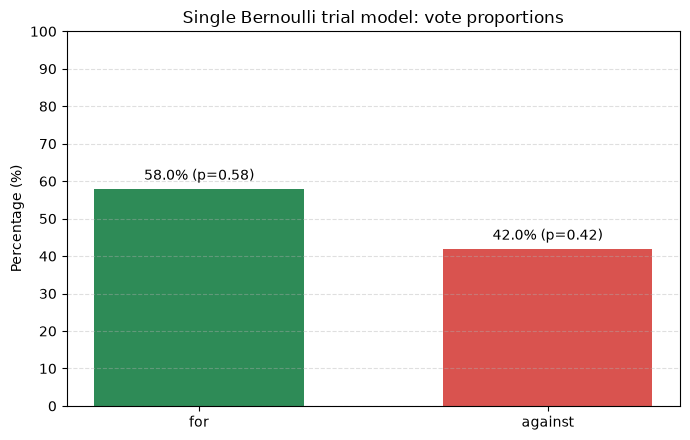

In [10]:
# Data for the scaled graphic
labels = ["for", "against"]
proportions = [p_for, p_against]
percentages = [pct_for, pct_against]
colors = ["#2e8b57", "#d9534f"]

# Initialize the plot
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, percentages, color=colors, width=0.6)

# Explicit scale so the reader can interpret values
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.set_ylabel("Percentage (%)")
ax.set_title("Single Bernoulli trial model: vote proportions")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Annotate bars with exact percentages and probabilities
for bar, pct, p in zip(bars, percentages, proportions):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{pct:.1f}% (p={p:.2f})",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

## 2) Why these computations are trustworthy

- The percentage computations use only arithmetic from the Bernoulli model: $p$ and $1-p$.
- The expectation formula $\mathbb{E}[X]=\sum_x x\,\mathbb{P}(X=x)$ for a discrete random variable is standard probability theory.
- `matplotlib` is used only for rendering the chart; the plotted values are the same explicitly computed numbers shown above.
- Internal consistency is verified by the check $0.58+0.42=1.00$.

Hence the numerical and graphical outputs are directly tied to the model assumptions and standard results.